Подготовка


In [1]:
!pip install category_encoders -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import category_encoders as ce
from scipy.stats import skew, kurtosis

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

df = pd.read_csv('train.csv')

Быстрый обзор

In [2]:
print(f"Формат данных: {df.shape}")
display(df.head(3))

df.info()

display(df.describe().T)
display(df.describe(include="object").T)

print(f"Дубликатов: {df.duplicated().sum()}")
missing = df.isnull().sum()
print("Топ пропусков:\n", missing[missing > 0].sort_values(ascending=False).head(10))

Формат данных: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


Дубликатов: 0
Топ пропусков:
 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64


Очистка и заполнение пропусков (с обоснованием)

In [3]:
# Объект отсутствует, заполняем None
none_features = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
for col in none_features:
    df[col] = df[col].fillna('None')

# Отсутствие числового поля, заполняем 0
zero_features = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in zero_features:
    df[col] = df[col].fillna(0)

# Заполняем медианой по району, в одном районе дома примерно одной длинны
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# Заполняем модой там, где мало пропусков / очень малый разброс
mode_features = ['Electrical', 'MSZoning', 'Utilities', 'Functional', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'SaleType']
for col in mode_features:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) == 0:
    print("Нет пропусков.")
else:
    print("Оставшиеся пропуски:")
    print(missing_data)

Нет пропусков.


Мои методы для вычислений и сравнение с pandas.

Результаты для цен оказались одинаковы, далее я буду использовать встроенные методы.

Дисперсия показывает как далеко отклоняются значенияю

Ассиметрия как сильно отличаются распределени слева и справа от среднего.

Эксцесс показывает насколько много элементов на концах.

In [4]:
def calculate_manual_stats(data):
    n = len(data)
    mean = sum(data) / n

    diffs = [x - mean for x in data]
    sq_diffs = [x**2 for x in diffs]
    cub_diffs = [x**3 for x in diffs]
    fourth_diffs = [x**4 for x in diffs]

    # Дисперсия
    var = sum(sq_diffs) / (n - 1)
    std = var**0.5

    # Асимметрия
    skew = (n * sum(cub_diffs)) / ((n - 1) * (n - 2) * (std**3))

    # Эксцесс
    term1 = (n * (n + 1) * sum(fourth_diffs)) / ((n - 1) * (n - 2) * (n - 3) * (std**4))
    term2 = (3 * (n - 1)**2) / ((n - 2) * (n - 3))
    kurt = term1 - term2

    # Мода
    counts = {}
    for x in data:
        counts[x] = counts.get(x, 0) + 1
    max_count = max(counts.values())
    mode = [k for k, v in counts.items() if v == max_count][0]

    return {"Variance": var, "Skewness": skew, "Kurtosis": kurt, "Mode": mode}

prices = df['SalePrice'].tolist()
manual = calculate_manual_stats(prices)

comparison = pd.DataFrame({
    'Metric': ['Variance', 'Skewness', 'Kurtosis', 'Mode'],
    'My': [manual['Variance'], manual['Skewness'], manual['Kurtosis'], manual['Mode']],
    'Pandas': [df['SalePrice'].var(), df['SalePrice'].skew(), df['SalePrice'].kurt(), df['SalePrice'].mode()[0]]
})

print("Сравнение ручного расчета и встроенных методов:")
display(comparison)

Сравнение ручного расчета и встроенных методов:


,Metric,My,Pandas
0,Variance,6.311111e+09,6.311111e+09
1,Skewness,1.882876e+00,1.882876e+00
2,Kurtosis,6.536282e+00,6.536282e+00
3,Mode,1.400000e+05,1.400000e+05


Расширеная статистика

In [5]:
target = df['SalePrice']

print(f"Min: {target.min()}, Max: {target.max()}")
print(f"Mean: {target.mean():.2f}, Median: {target.median():.2f}")
print(f"Mode: {target.mode()[0]}")

print("\nПерцентили (5, 25, 50, 75, 95):")
print(target.quantile([0.05, 0.25, 0.50, 0.75, 0.95]))

print(f"\nДисперсия : {target.var():.2f}")
print(f"Асимметрия : {target.skew():.2f}")
print(f"Эксцесс : {target.kurt():.2f}")

Min: 34900, Max: 755000
Mean: 180921.20, Median: 163000.00
Mode: 140000

Перцентили (5, 25, 50, 75, 95):
0.05     88000.0
0.25    129975.0
0.50    163000.0
0.75    214000.0
0.95    326100.0
Name: SalePrice, dtype: float64

Дисперсия : 6311111264.30
Асимметрия : 1.88
Эксцесс : 6.54


Новые признаки

In [6]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

df['TotalBathrooms'] = (df['FullBath'] + (0.5 * df['HalfBath']) +
                        df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))

df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                      df['3SsnPorch'] + df['ScreenPorch'])

display(df[['TotalSF', 'TotalBathrooms', 'TotalPorchSF']].head())

,TotalSF,TotalBathrooms,TotalPorchSF
0,2566,3.5,61
1,2524,2.5,0
2,2706,3.5,42
3,2473,2.0,307
4,3343,3.5,84


Энкодинг

In [7]:
print(f"Размер до энкодинга: {df.shape}")
display(df.head(3))

df_enc = df.copy()

for col in ['Condition1', 'Condition2']:
    series = df_enc[col].value_counts(normalize=True)
    rare_categories = series[series < 0.01].index
    df_enc[col] = df_enc[col].replace(rare_categories, 'Other')

hash_enc = ce.HashingEncoder(cols=['Neighborhood', 'Condition1', 'Condition2'], n_components=8)
df_enc = hash_enc.fit_transform(df_enc)

df_enc = pd.get_dummies(df_enc, columns=['CentralAir'], drop_first=True)

print(f"Размер после энкодинга: {df_enc.shape}")
display(df_enc.head(3))

Размер до энкодинга: (1460, 84)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBathrooms,TotalPorchSF
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500,2566,3.5,61
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500,2524,2.5,0
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500,2706,3.5,42


Размер после энкодинга: (1460, 89)


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,TotalBathrooms,TotalPorchSF,CentralAir_Y
0,0,0,1,2,0,0,0,0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500,2566,3.5,61,True
1,0,0,0,1,1,1,0,0,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500,2524,2.5,0,True
2,0,0,1,2,0,0,0,0,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500,2706,3.5,42,True


# Визуализация


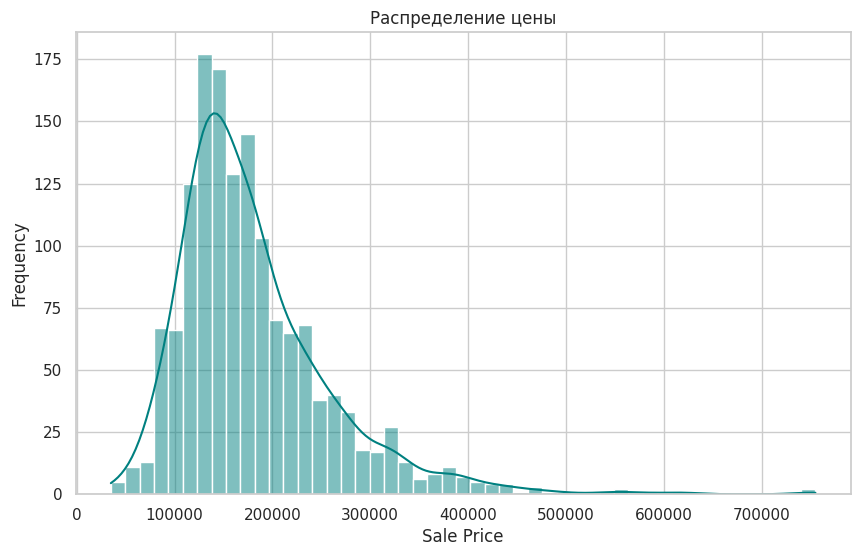

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='teal')
plt.title('Распределение цены')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

Большой хвост справа, большая плотность возле медианы

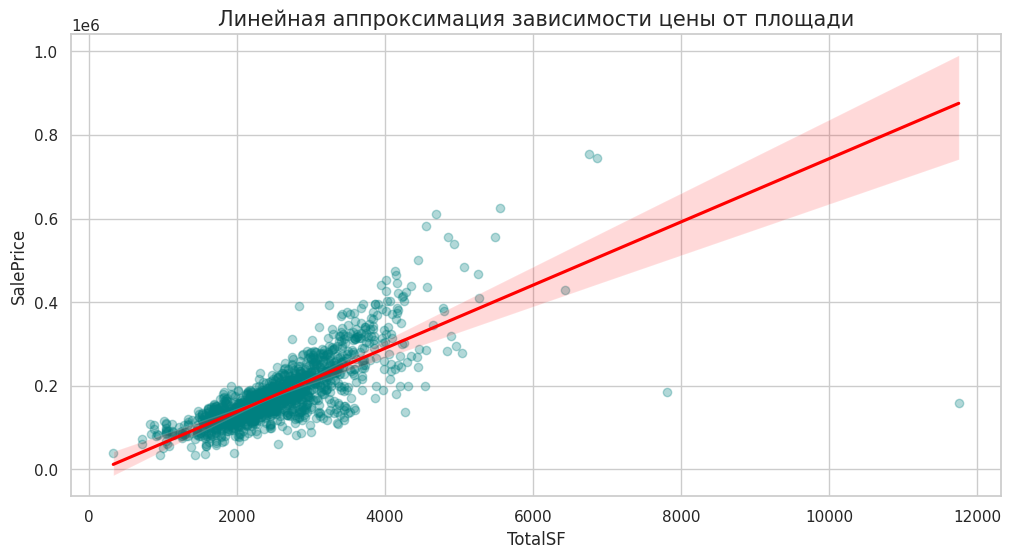

In [9]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df_enc, x='TotalSF', y='SalePrice', scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Линейная аппроксимация зависимости цены от площади', fontsize=15)
plt.show()

Апроксимация хорошо работает для малых площадей, видны дома с огромной площадью и малой ценой.

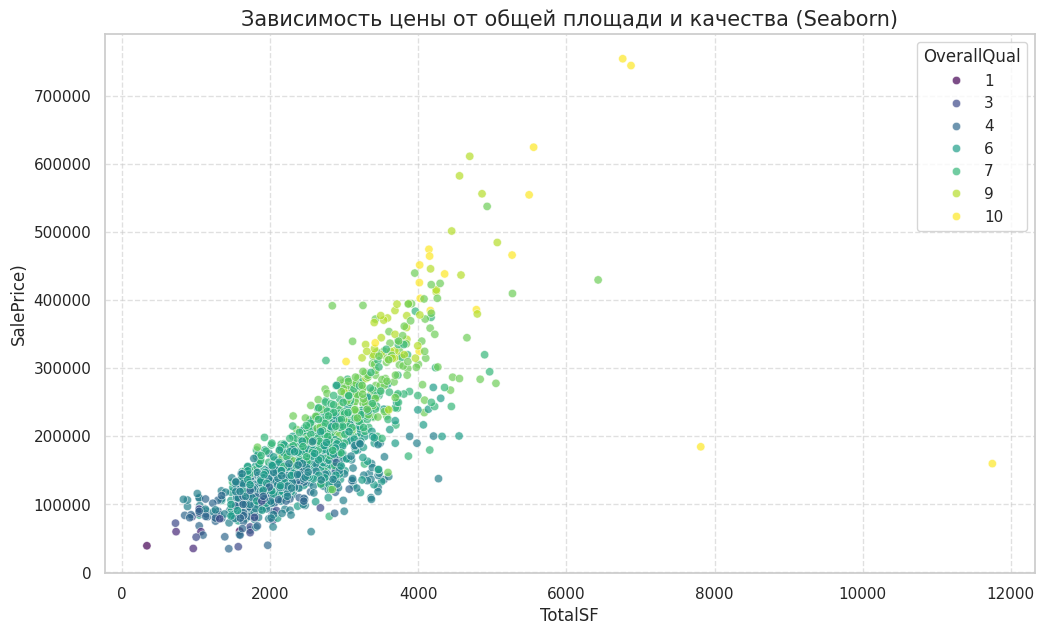

In [10]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_enc, x='TotalSF', y='SalePrice', hue='OverallQual', palette='viridis', alpha=0.7)
plt.title('Зависимость цены от общей площади и качества (Seaborn)', fontsize=15)
plt.xlabel('TotalSF')
plt.ylabel('SalePrice)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

График похож на экспоненциальный

/tmp/ipykernel_18380/1538683210.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='BldgType', y='SalePrice', palette='Set2')


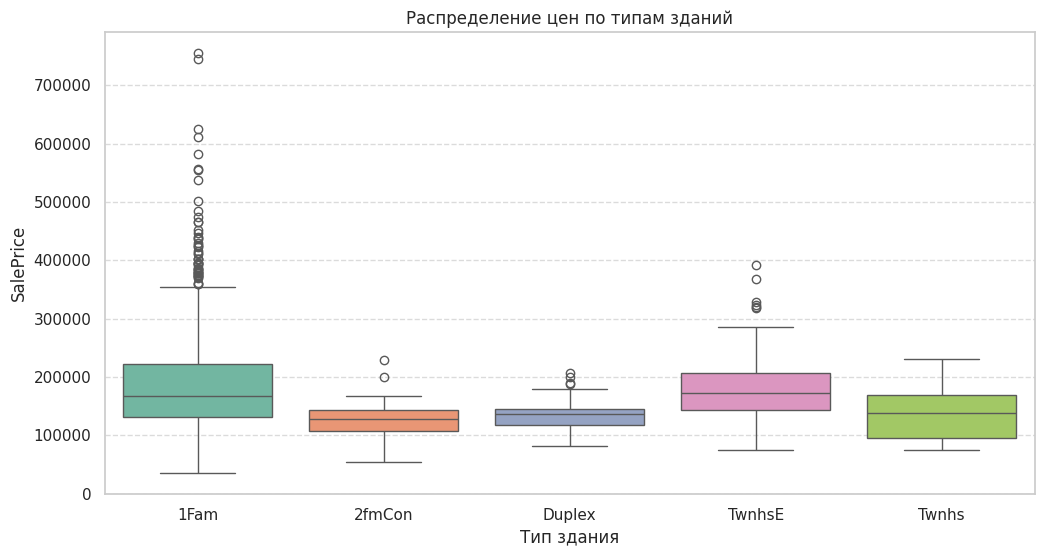

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='BldgType', y='SalePrice', palette='Set2')
plt.title('Распределение цен по типам зданий')
plt.xlabel('Тип здания')
plt.ylabel('SalePrice')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


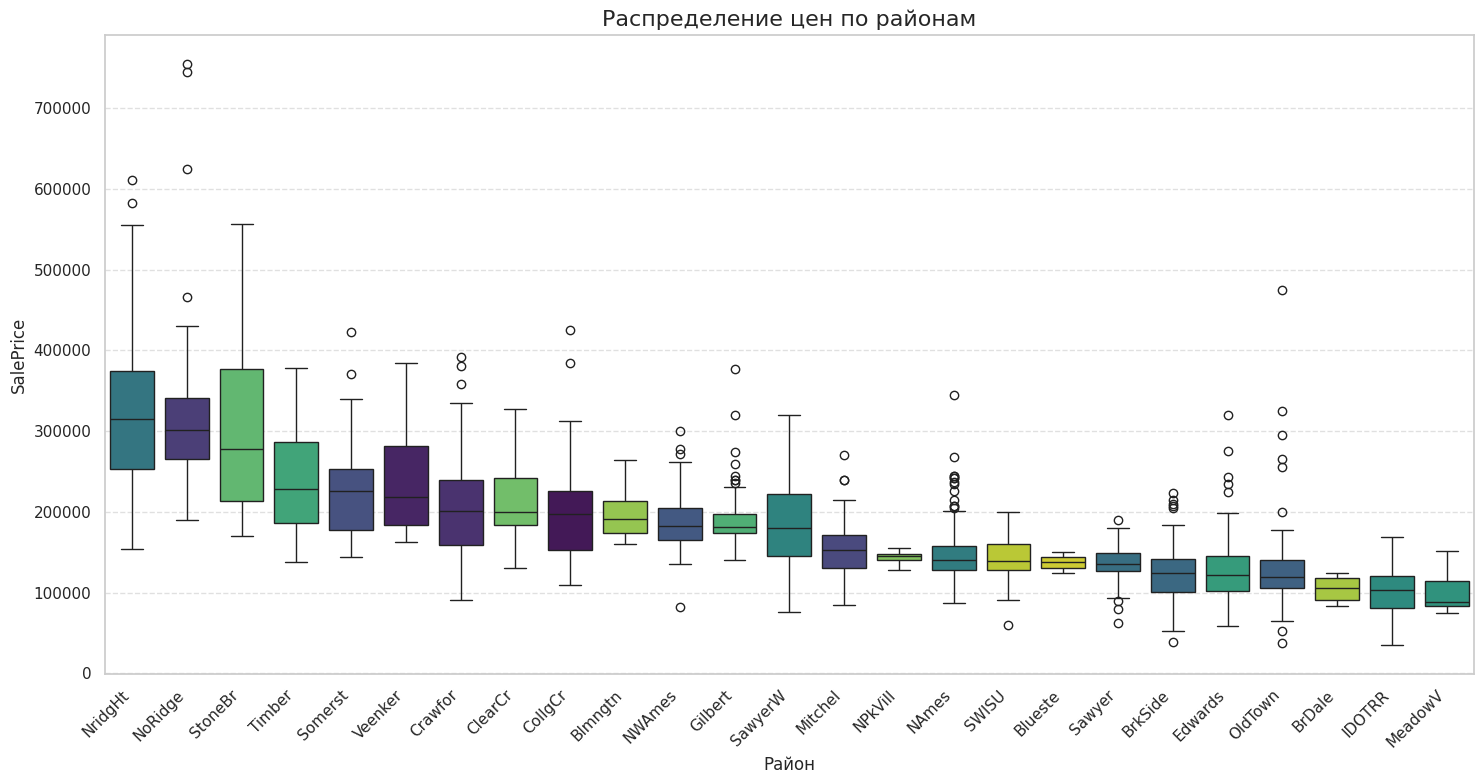

In [12]:
plt.figure(figsize=(15, 8))
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, palette='viridis', hue='Neighborhood', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Распределение цен по районам', fontsize=16)
plt.xlabel('Район')
plt.ylabel('SalePrice')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Корреляция 15 важнейших для цены признаков


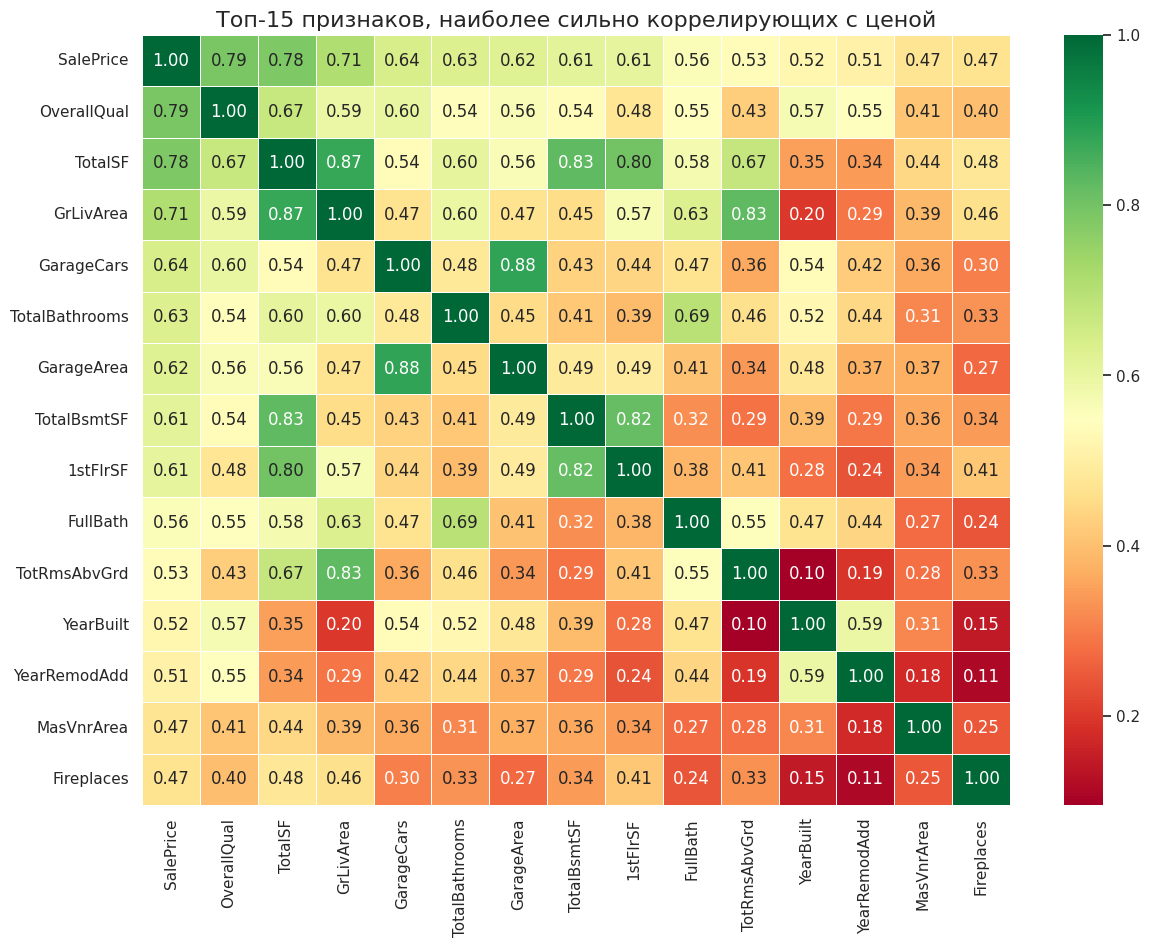

In [13]:
plt.figure(figsize=(14, 10))

numeric_df = df_enc.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

top_corr_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(15).index

top_corr_matrix = numeric_df[top_corr_features].corr()

sns.heatmap(top_corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Топ-15 признаков, наиболее сильно коррелирующих с ценой', fontsize=16)
plt.show()

# Выводы

## Наблюдения
1. Параметры площади имеют сильную корреляцию с ценой и друг другом.
2. Если в доме чего-то много, то это кореллирует с площадью и ценой.
3. Районы сильно влияют на цену
4. На рынке преобладают бюджетные дома, но есть достаточно очень дорогих.
5. Мы изучили как соотносятся цены разных типов домов, это влияние не кажется сильным.
6. Гаражи - самая важная дополнительная фишка
7. Качество отделки - самое важное

## Бизнес Идеи
1. Строить больше гаражей
2. Строить из качественных материалов

## ИИ
Я плохо знаком с функциями библиотек, и постоянно спрашивал у ии как написать что-то, но структуру делал сам